# N-Terminal Similarity Analysis — TA Proteins

This notebook explores sequence similarity in the **N-terminal region** of
tail-anchored (TA) proteins using the results from `IDR/idr_analysis.py`.

## What this notebook does

1. **Load** the TA protein IDR results
2. **Extract** N-terminal windows (full region before the TMD)
3. **Sequence logo** — information-content logo of the right-aligned windows
4. **Pairwise identity heatmap** — all-vs-all % identity to spot sub-groups
5. **CIDER metrics** — FCR, NCPR, κ, Ω distributions to characterise IDR chemistry
6. **K-mer enrichment** — over-represented short peptides (k = 3–5) using a binomial test

### Dependencies

```
pip install logomaker matplotlib pandas numpy requests scipy
```

All are listed in `IDR/requirements.txt`.


In [1]:
import sys, os, importlib

# Make IDR module importable when running from the notebooks/ directory
sys.path.insert(0, os.path.join(os.getcwd(), "..", "IDR"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Always reload so edits to the IDR modules are picked up without a kernel restart
import idr_analysis, nterm_analysis
importlib.reload(idr_analysis)
importlib.reload(nterm_analysis)

from idr_analysis import fetch_sequence
from nterm_analysis import (
    extract_windows_from_df,
    right_align_sequences,
    plot_sequence_logo,
    pairwise_identity_matrix,
    plot_identity_heatmap,
    build_cider_dataframe,
    format_fasta,
    kmer_enrichment,
)

%matplotlib inline
plt.rcParams["figure.dpi"] = 100


## 1 — Load TA protein data

In [2]:
# Adjust path if running from a different directory
TA_RESULTS = os.path.join("..", "IDR", "ta_idr_results.csv")

ta_df = pd.read_csv(TA_RESULTS)
print(f"Loaded {len(ta_df)} TA proteins")
ta_df[["Entry", "Entry.Name", "Length", "Transmembrane", "cterm_distance"]].head()

Loaded 183 TA proteins


,Entry,Entry.Name,Length,Transmembrane,cterm_distance
0,A4D256,CC14C_HUMAN,447,"TRANSMEM 426..446; /note=""Helical""; /evidence=...",1
1,A6NFA1,TIKI2_HUMAN,517,"TRANSMEM 495..515; /note=""Helical""; /evidence=...",2
2,A6NI73,LIRA5_HUMAN,299,"TRANSMEM 269..289; /note=""Helical""; /evidence=...",10
3,O00241,SIRB1_HUMAN,398,"TRANSMEM 372..392; /note=""Helical""; /evidence=...",6
4,O00526,UPK2_HUMAN,184,"TRANSMEM 156..176; /note=""Helical""; /evidence=...",8


## 2 — Download sequences and extract N-terminal windows

Sequences are fetched from the UniProt REST API (one request per protein).
Re-run once and cache to avoid repeated downloads.

By default the **full N-terminal region** (everything before the last TMD) is
extracted.  Pass `window_size=N` to restrict to the *N* residues immediately
upstream of the TMD boundary.


In [3]:
SEQUENCE_CACHE = os.path.join("..", "IDR", "ta_sequences.csv")
WINDOW_SIZE = None  # None = full N-terminal region up to TMD (recommended for TA proteins)

# ── Load or download sequences ────────────────────────────────────────────────
if os.path.exists(SEQUENCE_CACHE):
    seq_df = pd.read_csv(SEQUENCE_CACHE)
    sequences = dict(zip(seq_df["Entry"], seq_df["sequence"]))
    print(f"Loaded {len(sequences)} cached sequences")
else:
    print("Fetching sequences from UniProt (this may take a few minutes)...")
    sequences = {}
    for acc in ta_df["Entry"]:
        seq = fetch_sequence(acc)
        if seq:
            sequences[acc] = seq
    pd.DataFrame(
        [{"Entry": k, "sequence": v} for k, v in sequences.items()]
    ).to_csv(SEQUENCE_CACHE, index=False)
    print(f"Downloaded and cached {len(sequences)} sequences")

# ── Extract windows ───────────────────────────────────────────────────────────
windows = extract_windows_from_df(ta_df, sequences, window_size=WINDOW_SIZE)
label = f"≤{WINDOW_SIZE} residues before TMD" if WINDOW_SIZE else "full N-terminal region"
print(f"Extracted {len(windows)} N-terminal windows ({label})")


Loaded 183 cached sequences
Extracted 182 N-terminal windows (full N-terminal region)


count     182.000000
mean      399.241758
std       332.458109
min       108.000000
25%       201.250000
50%       286.000000
75%       509.750000
max      3235.000000
Name: window_length, dtype: float64


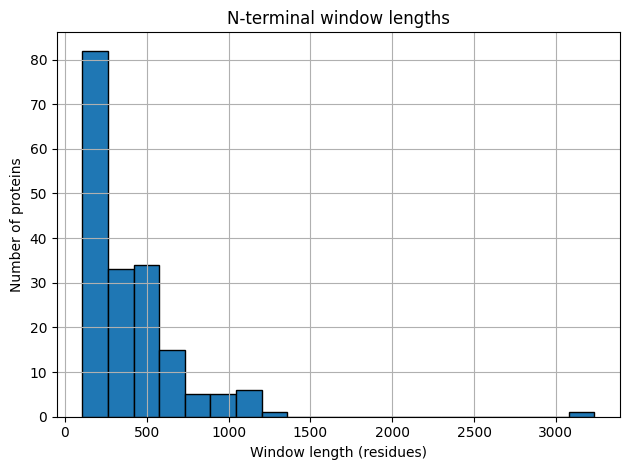

In [4]:
# Quick look at window lengths
lengths = pd.Series([len(v) for v in windows.values()], name="window_length")
print(lengths.describe())
lengths.hist(bins=20, edgecolor="k")
plt.xlabel("Window length (residues)")
plt.ylabel("Number of proteins")
plt.title("N-terminal window lengths")
plt.tight_layout()
plt.show()

## 3 — Sequence logo

Windows are **right-aligned** so position 0 (rightmost) corresponds to the
residue immediately before the TMD in every protein.  The logo is in
*information content* (bits) — taller letters indicate stronger conservation.

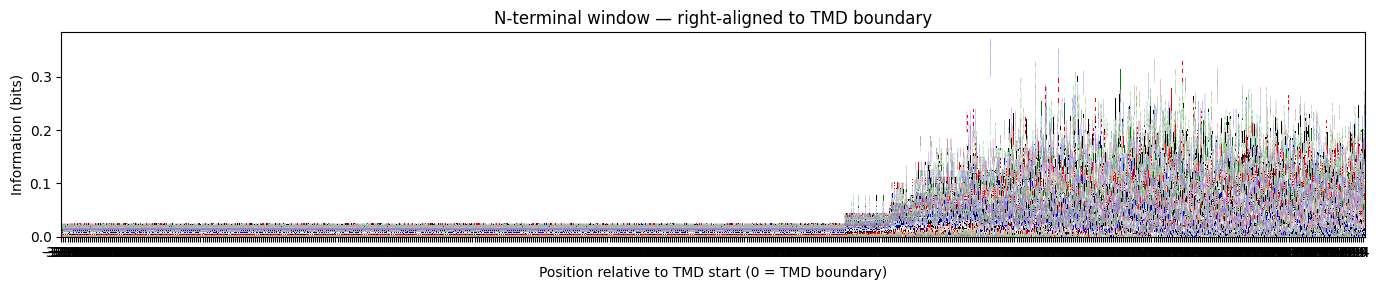

In [5]:
window_list = list(windows.values())
aligned = right_align_sequences(window_list)

fig, ax = plt.subplots(figsize=(14, 3))
plot_sequence_logo(
    aligned,
    ax=ax,
    title="N-terminal window — right-aligned to TMD boundary",
)

# Label x-axis: distance from TMD (negative = upstream)
n_pos = len(aligned[0])
ax.set_xticks(range(0, n_pos, 5))
ax.set_xticklabels([f"{-(n_pos - 1 - i)}" for i in range(0, n_pos, 5)])
ax.set_xlabel("Position relative to TMD start (0 = TMD boundary)")

plt.tight_layout()
plt.show()

## 4 — Pairwise identity heatmap

An all-vs-all % identity matrix of the N-terminal windows reveals whether
there are **subgroups** of similar sequences hiding in the TA dataset.
If clear clusters appear, consider running motif discovery (Section 6)
separately on each cluster.

In [6]:
# Use only proteins that have a window (some may lack a parsed TMD)
window_accs  = [acc for acc in ta_df["Entry"] if acc in windows]
window_seqs  = [windows[acc] for acc in window_accs]

# Gene names for tick labels (fall back to accession)
acc_to_gene = dict(zip(ta_df["Entry"], ta_df.get("Gene.Names", ta_df["Entry"])))
labels = [
    str(acc_to_gene.get(acc, acc)).split()[0] if pd.notna(acc_to_gene.get(acc)) else acc
    for acc in window_accs
]

pct_mat = pairwise_identity_matrix(window_seqs)
print(f"Identity matrix: {pct_mat.shape[0]} × {pct_mat.shape[1]}")
print(f"Mean off-diagonal identity: {pct_mat[pct_mat < 100].mean():.1f}%")

Identity matrix: 182 × 182
Mean off-diagonal identity: 6.0%


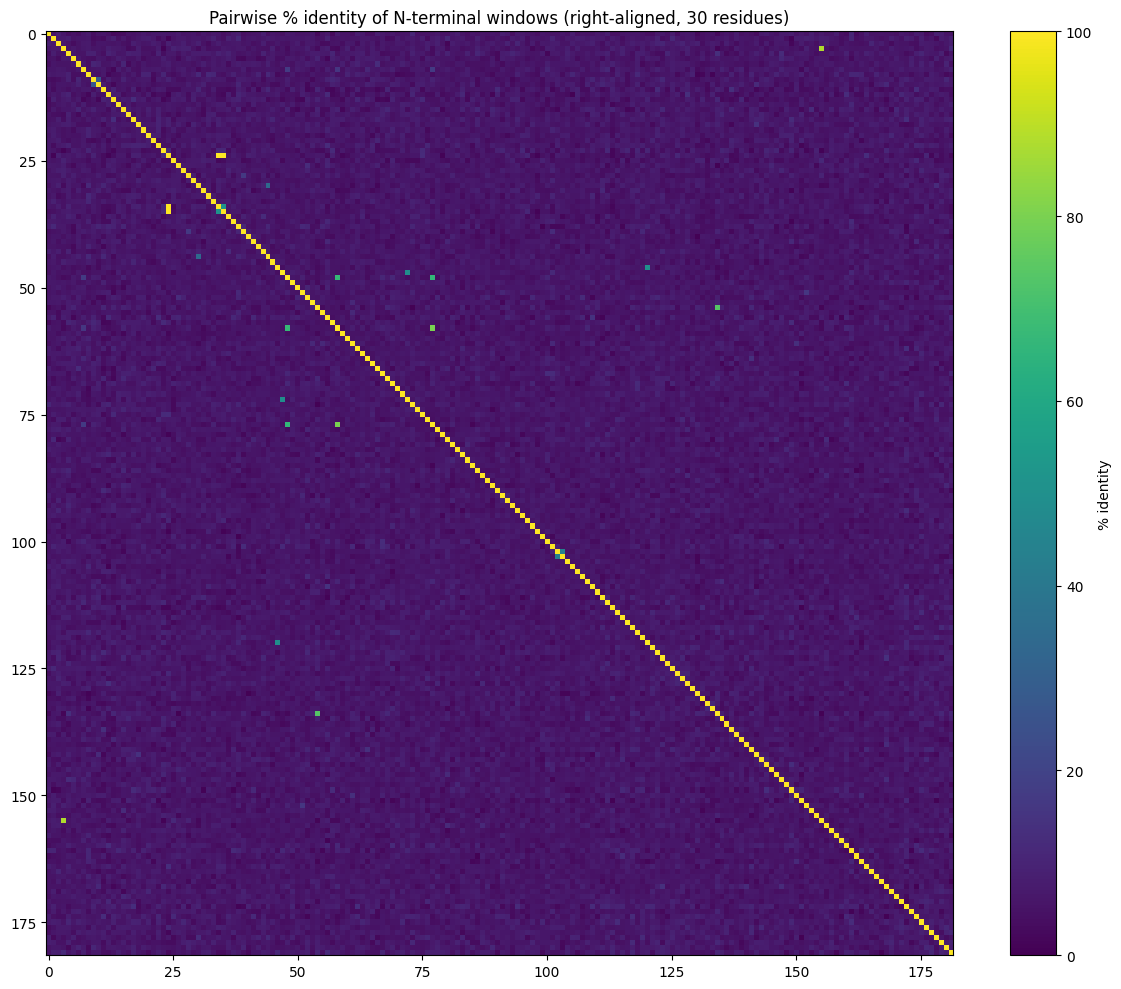

In [7]:
fig, ax = plt.subplots(figsize=(12, 10))
plot_identity_heatmap(
    pct_mat, labels, ax=ax,
    title="Pairwise % identity of N-terminal windows (right-aligned, 30 residues)",
)
plt.tight_layout()
plt.show()

## 5 — CIDER-style IDR metrics

Four complementary metrics characterise the charge composition and patterning
of each N-terminal window:

| Metric | Meaning | Range |
|--------|---------|-------|
| **FCR** | Fraction of charged residues (K, R, D, E) | [0, 1] |
| **NCPR** | Net charge per residue (positive = cationic) | [−1, 1] |
| **κ** | Charge asymmetry (0 = well-mixed, 1 = segregated) | [0, 1] |
| **Ω** | Clustering of charged + Pro residues (1 = clustered) | [0, 1] |

Reference: Das & Pappu (2013) *PNAS* 110:13392; Holehouse *et al.* (2017).

In [8]:
cider_df = build_cider_dataframe(window_accs, windows)

# Add gene names for display
cider_df["gene"] = cider_df["Entry"].map(acc_to_gene).fillna(cider_df["Entry"])

print("CIDER metrics summary:")
print(cider_df[["fcr", "ncpr", "kappa", "omega"]].describe().round(3))

CIDER metrics summary:
           fcr     ncpr    kappa    omega
count  182.000  182.000  182.000  182.000
mean     0.238   -0.009    0.232    0.176
std      0.055    0.038    0.055    0.039
min      0.085   -0.133    0.116    0.081
25%      0.200   -0.029    0.196    0.155
50%      0.235   -0.009    0.225    0.176
75%      0.264    0.010    0.255    0.199
max      0.394    0.136    0.449    0.286


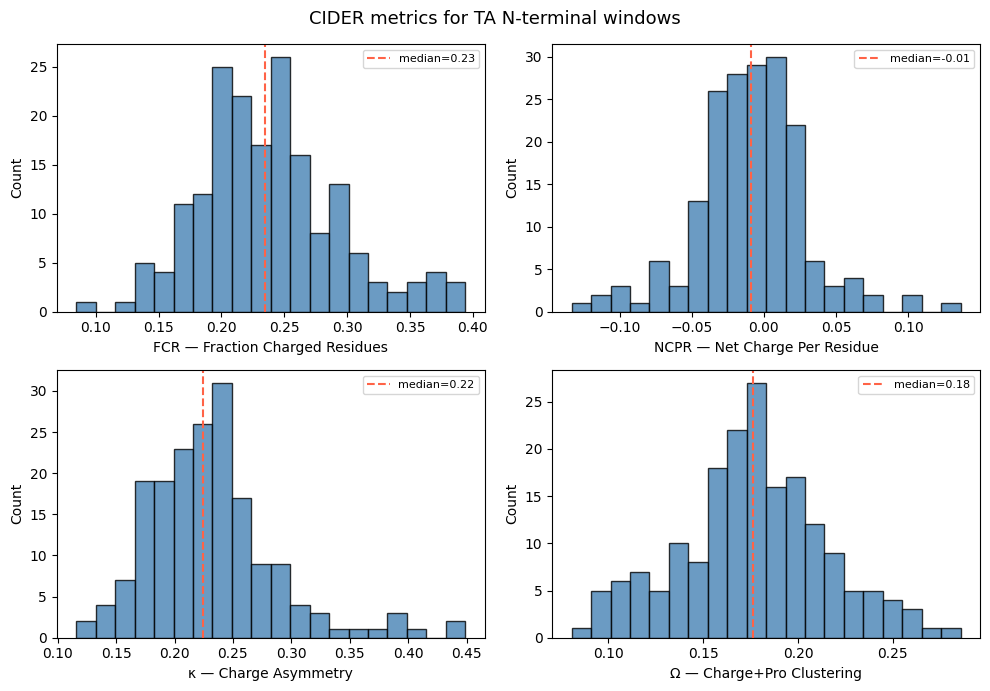

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(10, 7))
metric_labels = {
    "fcr":   "FCR — Fraction Charged Residues",
    "ncpr":  "NCPR — Net Charge Per Residue",
    "kappa": "κ — Charge Asymmetry",
    "omega": "Ω — Charge+Pro Clustering",
}
for ax, (metric, label) in zip(axes.flat, metric_labels.items()):
    data = cider_df[metric].dropna()
    ax.hist(data, bins=20, edgecolor="k", color="steelblue", alpha=0.8)
    ax.axvline(data.median(), color="tomato", linestyle="--", label=f"median={data.median():.2f}")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

fig.suptitle("CIDER metrics for TA N-terminal windows", fontsize=13)
plt.tight_layout()
plt.show()

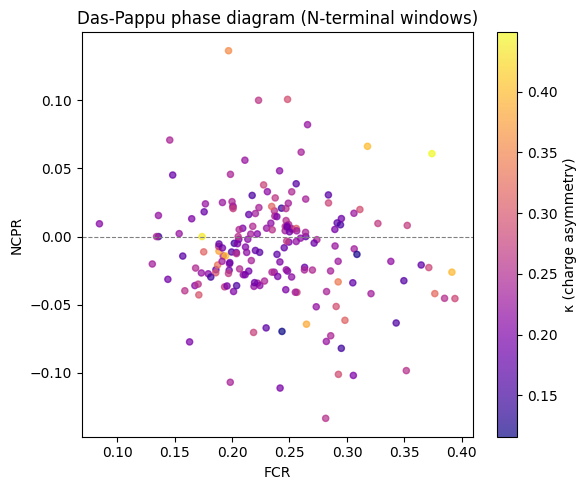

In [10]:
# FCR vs NCPR scatter: Das-Pappu phase diagram style
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(
    cider_df["fcr"], cider_df["ncpr"],
    c=cider_df["kappa"], cmap="plasma", s=20, alpha=0.7
)
plt.colorbar(sc, ax=ax, label="κ (charge asymmetry)")
ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_xlabel("FCR")
ax.set_ylabel("NCPR")
ax.set_title("Das-Pappu phase diagram (N-terminal windows)")
plt.tight_layout()
plt.show()

## 6 — Over-represented k-mer analysis

De-novo short-motif discovery by k-mer enrichment.  For each k-mer of length
k = 3, 4, and 5 we count occurrences across all N-terminal windows and compare
to the frequency expected under an independence model built from the observed
single amino-acid composition.

**Enrichment** = observed frequency / expected frequency.  
**P-value**: one-sided binomial test (SciPy `binomtest`), asking whether the
k-mer appears *more often* than expected by chance.  Only k-mers seen ≥ 3 times
are reported.


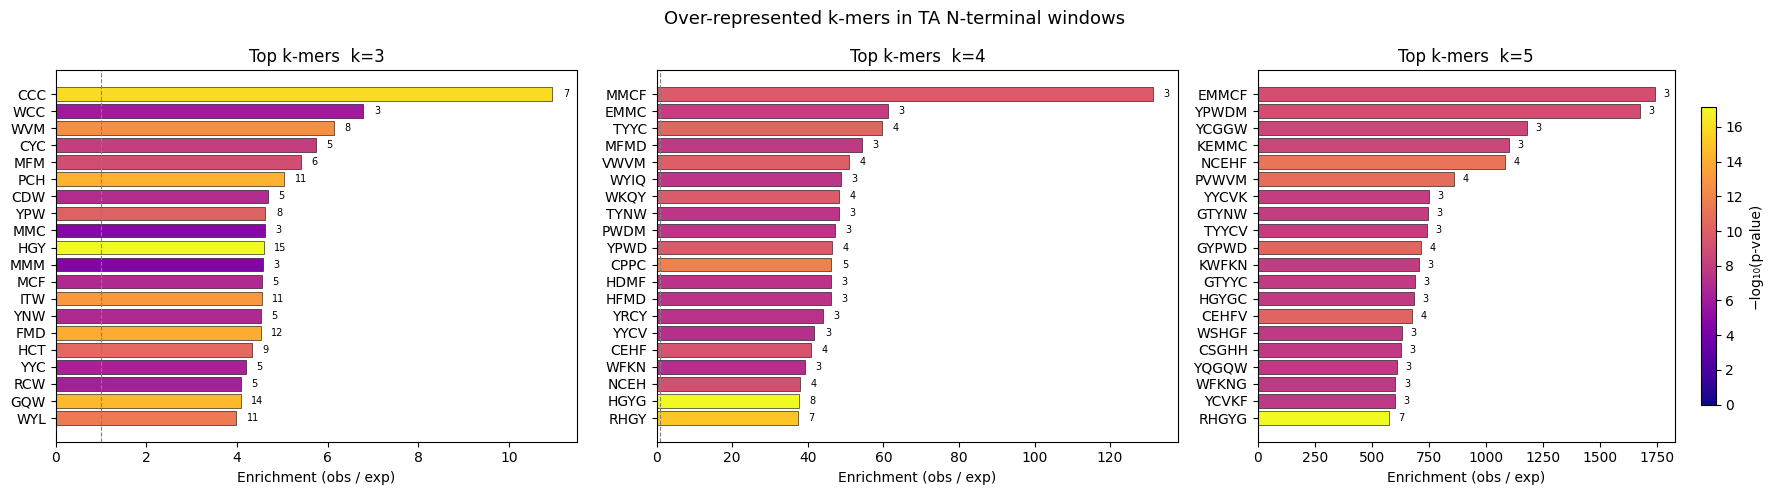


── k=3 top 10 ──────────────────────────────
kmer  count  enrichment   pvalue
 CCC      7          11 4.93e-06
 WCC      3        6.79   0.0104
 WVM      8        6.13 6.56e-05
 CYC      5        5.73  0.00205
 MFM      6        5.42 0.000999
 PCH     11        5.04 1.83e-05
 CDW      5        4.68   0.0048
 YPW      8        4.63 0.000432
 MMC      3        4.62   0.0283
 HGY     15        4.59  1.9e-06

── k=4 top 10 ──────────────────────────────
kmer  count  enrichment   pvalue
MMCF      3         131 1.95e-06
EMMC      3        61.1  1.9e-05
TYYC      4        59.7 7.95e-07
MFMD      3        54.4 2.68e-05
VWVM      4        50.8  1.5e-06
WYIQ      3        48.7 3.71e-05
WKQY      4        48.4 1.82e-06
TYNW      3        48.3 3.81e-05
PWDM      3        47.2 4.09e-05
YPWD      4        46.5 2.14e-06

── k=5 top 10 ──────────────────────────────
 kmer  count  enrichment   pvalue
EMMCF      3    1.74e+03 8.53e-10
YPWDM      3    1.68e+03 9.56e-10
YCGGW      3    1.18e+03 2.73e-09


In [11]:
window_list = list(windows.values())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, k in zip(axes, [3, 4, 5]):
    df = kmer_enrichment(window_list, k=k, top_n=20, min_count=3)
    if df.empty:
        ax.set_title(f"k={k}: no enriched k-mers")
        continue

    # Colour bars by –log10(p-value)
    neg_log_p = -np.log10(df["pvalue"].clip(lower=1e-300))
    bars = ax.barh(df["kmer"][::-1], df["enrichment"][::-1],
                   color=plt.cm.plasma(neg_log_p[::-1] / (neg_log_p.max() or 1)),
                   edgecolor="k", linewidth=0.4)
    ax.set_xlabel("Enrichment (obs / exp)")
    ax.set_title(f"Top k-mers  k={k}")
    ax.axvline(1, color="grey", linestyle="--", linewidth=0.8)

    # Annotate counts
    for bar, count in zip(bars, df["count"][::-1]):
        ax.text(bar.get_width() + 0.02 * ax.get_xlim()[1],
                bar.get_y() + bar.get_height() / 2,
                str(count), va="center", fontsize=7)

sm = plt.cm.ScalarMappable(cmap="plasma",
                            norm=plt.Normalize(vmin=0, vmax=neg_log_p.max() or 1))
sm.set_array([])
fig.colorbar(sm, ax=axes[-1], label="−log₁₀(p-value)", shrink=0.8)

fig.suptitle("Over-represented k-mers in TA N-terminal windows", fontsize=13)
plt.tight_layout()
plt.show()

# Show top 10 for each k in a table
for k in [3, 4, 5]:
    df = kmer_enrichment(window_list, k=k, top_n=10, min_count=3)
    print(f"\n── k={k} top 10 ──────────────────────────────")
    print(df[["kmer", "count", "enrichment", "pvalue"]].to_string(index=False,
          float_format=lambda x: f"{x:.3g}"))


## Summary

| Analysis | What to look for |
|----------|------------------|
| Sequence logo | High-information positions near the TMD indicate conserved residues |
| Pairwise identity heatmap | Bright clusters = sub-groups; re-run k-mer enrichment per-cluster for sharper motifs |
| FCR distribution | Wide spread → heterogeneous charge content across TA proteins |
| NCPR distribution | Symmetric around 0 → balanced charge; skewed → net bias |
| κ distribution | High κ → charge-segregated IDRs (tend to collapse); low κ → mixed (tend to extend) |
| Ω distribution | High Ω → charge/Pro residues cluster; may indicate functional short motifs |
| Das-Pappu scatter | Reveals whether TA N-termini occupy distinct IDR phase-diagram regions |
| k-mer enrichment | Short over-represented peptides that recur more than expected from AA composition alone |


## 7 — Foldseek structural similarity (preTMD region)

Structural similarity in the N-terminal region (residues before the last TMD)
using **Foldseek** TM-align all-vs-all comparison on **AlphaFold v4** structures.

### Why structure over sequence?
Sequence identity in intrinsically disordered / low-complexity regions is a poor
proxy for functional relatedness.  Foldseek compares backbone geometry and can
uncover structural homology invisible to BLAST or k-mer methods.

### Pipeline steps
1. Download AlphaFold PDB structures (cached locally after first run)
2. Trim each structure to residues **before** the TMD start (preTMD region)
3. Run Foldseek all-vs-all with TM-align (`--exhaustive-search`)
4. Build a symmetric TM-score matrix
5. Visualise as a **clustered heatmap** and a **UPGMA dendrogram**

> **TM-score interpretation**: ≥ 0.5 indicates the same fold (statistical
> significance); < 0.2 is essentially random; 1.0 is identical.

References: van Kempen *et al.* (2024) *Nature Biotechnology* 42:243; Zhang &
Skolnick (2004) *Proteins* 57:702.


In [12]:
import importlib, sys, os

# Ensure the IDR directory is importable
sys.path.insert(0, os.path.join(os.getcwd(), "..", "IDR"))

import foldseek_pipeline
importlib.reload(foldseek_pipeline)

from foldseek_pipeline import (
    setup_foldseek,
    run_pipeline,
    plot_tmscore_heatmap,
    plot_tmscore_dendrogram,
    tmscore_distribution,
    top_hits,
)

# Locate (or install) foldseek — this is a no-op if already installed
foldseek_bin = setup_foldseek()
print(f"foldseek binary: {foldseek_bin}")


foldseek binary: /home/codespace/.local/bin/foldseek


In [13]:
# ── Run the full pipeline ──────────────────────────────────────────────────────
# ta_df and sequences are already loaded from Section 1/2 above.
# Work directory is created inside IDR/ so everything stays collocated.
WORK_DIR = os.path.join("..", "IDR", "foldseek_work")

import logging
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

results = run_pipeline(
    ta_df,
    sequences,
    work_dir=WORK_DIR,
    foldseek_bin=foldseek_bin,
    force_rerun=False,    # set True to re-run even if results.m8 already exists
    threads=4,
)

print(f"\n{'─'*60}")
print(f"  Proteins with AlphaFold structures : {len(results['structure_paths'])}")
print(f"  Trimmed preTMD structures           : {len(results['trimmed_paths'])}")
print(f"  Foldseek result rows                : {len(results['foldseek_df'])}")
print(f"  TM-score matrix shape               : {results['tmscore_matrix'].shape}")
print(f"{'─'*60}")


INFO foldseek_pipeline: Parsing TMD positions for 183 proteins …
INFO foldseek_pipeline: 182 / 183 proteins have a parseable TMD start
INFO foldseek_pipeline: Downloading AlphaFold structures to ../IDR/foldseek_work/alphafold_structures …
INFO foldseek_pipeline: Structures: 25/182 downloaded (25 available)
INFO foldseek_pipeline: Structures: 50/182 downloaded (50 available)
INFO foldseek_pipeline: Structures: 75/182 downloaded (74 available)
INFO foldseek_pipeline: Structures: 100/182 downloaded (99 available)
INFO foldseek_pipeline: Structures: 125/182 downloaded (124 available)
INFO foldseek_pipeline: Structures: 150/182 downloaded (149 available)
INFO foldseek_pipeline: Structures: 175/182 downloaded (174 available)
INFO foldseek_pipeline: Structures: 182/182 downloaded (181 available)
INFO foldseek_pipeline: 181 / 182 structures available from AlphaFold
INFO foldseek_pipeline: Trimming structures to preTMD region …
INFO foldseek_pipeline: Trimmed 181 / 181 structures to preTMD regi

RuntimeError: Command failed (exit 1):
  /home/codespace/.local/bin/foldseek convertalis ../IDR/foldseek_work/foldseek/structureDB ../IDR/foldseek_work/foldseek/structureDB ../IDR/foldseek_work/foldseek/resultDB ../IDR/foldseek_work/foldseek/results.m8 --format-output query,target,alntmscore,lddt,rmsd,prob,evalue,bits,alnlen,qlen,tlen
stdout: convertalis ../IDR/foldseek_work/foldseek/structureDB ../IDR/foldseek_work/foldseek/structureDB ../IDR/foldseek_work/foldseek/resultDB ../IDR/foldseek_work/foldseek/results.m8 --format-output query,target,alntmscore,lddt,rmsd,prob,evalue,bits,alnlen,qlen,tlen 

MMseqs Version:        	941cd33ff0771cd2e3f144e3293e22a2b87e9fda
Substitution matrix    	aa:3di.out,nucl:3di.out
Alignment format       	0
Format alignment output	query,target,alntmscore,lddt,rmsd,prob,evalue,bits,alnlen,qlen,tlen
Gap open cost          	aa:10,nucl:10
Gap extension cost     	aa:1,nucl:1
Database output        	false
Preload mode           	0
Threads                	2
Compre

In [ ]:
# ── TM-score distribution ──────────────────────────────────────────────────────
import numpy as np

mat   = results["tmscore_matrix"]
n     = mat.shape[0]
mask  = ~np.eye(n, dtype=bool)
scores = mat[mask]

fig, ax = plt.subplots(figsize=(7, 4))
tmscore_distribution(mat, ax=ax, title="All-vs-all TM-score distribution (preTMD region)")

# Add vertical line at 0.5 ("same fold") is already drawn inside the function;
# annotate with % of pairs above threshold
frac = (scores >= 0.5).mean() * 100
ax.text(0.52, ax.get_ylim()[1] * 0.9, f"{frac:.1f}% ≥ 0.5", fontsize=9, color="grey")
plt.tight_layout()
plt.show()

print(f"Off-diagonal TM-score statistics:")
print(f"  mean   = {scores.mean():.4f}")
print(f"  median = {np.median(scores):.4f}")
print(f"  max    = {scores.max():.4f}")
print(f"  ≥ 0.5  = {(scores >= 0.5).sum()} pairs ({frac:.1f}%)")


In [ ]:
# ── Clustered TM-score heatmap ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 12))
plot_tmscore_heatmap(
    results["tmscore_matrix"],
    results["labels"],
    ax=ax,
    title="Foldseek all-vs-all TM-score — preTMD region (UPGMA ordering)",
)
plt.tight_layout()
plt.show()


In [ ]:
# ── UPGMA dendrogram ───────────────────────────────────────────────────────────
n = len(results["labels"])
fig, ax = plt.subplots(figsize=(max(12, n * 0.22), 5))
plot_tmscore_dendrogram(
    results["tmscore_matrix"],
    results["labels"],
    ax=ax,
    title="UPGMA dendrogram — preTMD structural distance (1 − TM-score)",
    color_threshold=0.5,
)
plt.tight_layout()
plt.show()


In [ ]:
# ── Top structural hits per protein ───────────────────────────────────────────
# Proteins whose preTMD folds most resemble another TA protein's preTMD.
# TM-score ≥ 0.5 = statistically significant structural similarity ("same fold").

hits_df = top_hits(results["foldseek_df"], top_n=5, min_tmscore=0.5)

# Annotate with gene names
acc_to_gene = dict(zip(ta_df["Entry"], ta_df.get("Gene.Names", ta_df["Entry"])))
for col in ("query", "target"):
    hits_df[f"{col}_gene"] = (
        hits_df[col].map(acc_to_gene)
                    .fillna(hits_df[col])
                    .str.split()
                    .str[0]
    )

display_cols = ["query_gene", "target_gene", "alntmscore", "lddt", "rmsd"]
print(f"Top structural hits (TM-score ≥ 0.5):  {len(hits_df)} pairs")
hits_df[display_cols].head(30)


In [ ]:
# ── Cross-tabulate sequence vs structural similarity ──────────────────────────
# Compare pairwise sequence identity (Section 4) with TM-score (Section 7) for
# the overlapping set of proteins.  Structural similarity without sequence
# similarity highlights convergent or deeply diverged homology.

# Sequence identity matrix (recomputed for the Foldseek accession set)
fs_accs = results["accessions"]
fs_seqs = [windows.get(acc, "") for acc in fs_accs]

# Filter to proteins that also have a window (some may lack one if seqs absent)
valid_idx = [i for i, s in enumerate(fs_seqs) if s]
valid_accs = [fs_accs[i] for i in valid_idx]
valid_seqs = [fs_seqs[i] for i in valid_idx]

from nterm_analysis import pairwise_identity_matrix
seq_mat = pairwise_identity_matrix(valid_seqs)
tm_mat  = results["tmscore_matrix"][np.ix_(valid_idx, valid_idx)]

n = len(valid_accs)
mask = ~np.eye(n, dtype=bool)
seq_flat = seq_mat[mask]
tm_flat  = tm_mat[mask]

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(seq_flat, tm_flat, s=4, alpha=0.3, color="steelblue")
ax.axhline(0.5, color="tomato",  linestyle="--", linewidth=0.8, label="TM=0.5 (same fold)")
ax.axvline(30,  color="grey",    linestyle="--", linewidth=0.8, label="30% seq identity")
ax.set_xlabel("Pairwise sequence identity (%)")
ax.set_ylabel("TM-score (preTMD)")
ax.set_title("Sequence identity vs structural similarity — preTMD pairs")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Structurally similar but sequence-dissimilar pairs (convergent / deep homology)
n_struct_only = ((tm_flat >= 0.5) & (seq_flat < 30)).sum()
n_total_pairs  = mask.sum()
print(f"Pairs with TM ≥ 0.5 but seq identity < 30%: "
      f"{n_struct_only} / {n_total_pairs} ({100*n_struct_only/n_total_pairs:.1f}%)")
